## Préparation de l'environnement

On importe les bibliothèques nécessaires et les fonctions réutilisables du module `src/preprocess.py`. Le notebook reste limité aux exercices 1 et 2 : exploration, nettoyage, encodage, normalisation et division train/test.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "agriculture_burundi.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import (
    load_data,
    report_missing,
    impute_missing,
    encode_categoricals,
    get_X_y,
    normalize_features,
    split_data,
    _continuous_numerical_columns,
)

DATA_PATH = PROJECT_ROOT / "data" / "agriculture_burundi.csv"
sns.set_theme(style="whitegrid", palette="Set2")
print('Initialisation terminée.')


Initialisation terminée.


## Exercice 1 — Chargement, Exploration et Qualité des Données

Cette première partie charge le fichier brut, vérifie la structure du dataset, analyse les valeurs manquantes et produit les premières visualisations descriptives.


### Q1 — Chargement des données et dimensions

On charge le fichier CSV brut puis on inspecte le nombre de lignes, le nombre de colonnes, la période couverte, les provinces et les cultures disponibles.


In [2]:
df = load_data(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Période couverte: {df['annee'].min()} - {df['annee'].max()}")
print(f"Nombre de provinces: {df['province'].nunique()}")
print("Provinces:", sorted(df['province'].dropna().unique()))
print(f"Nombre de cultures: {df['culture'].nunique()}")
print("Cultures:", sorted(df['culture'].dropna().unique()))
df.head()


Shape: (1620, 14)
Période couverte: 2015 - 2023
Nombre de provinces: 15
Provinces: ['Bubanza', 'Bujumbura Rural', 'Bururi', 'Cankuzo', 'Cibitoke', 'Gitega', 'Kayanza', 'Kirundo', 'Makamba', 'Muramvya', 'Muyinga', 'Mwaro', 'Ngozi', 'Rutana', 'Ruyigi']
Nombre de cultures: 6
Cultures: ['Bananier', 'Haricot', 'Manioc', 'Maïs', 'Patate douce', 'Sorgho']


,annee,saison,province,culture,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages,rendement_t_ha,production_totale_t,bonne_recolte
0,2015,A,Bujumbura Rural,Maïs,881,NaN,23.9,1.33,1.0,1,154,2.14,2.85,1.0
1,2015,A,Bujumbura Rural,Haricot,803,955.4,22.1,3.25,0.0,0,16,0.64,2.08,1.0
2,2015,A,Bujumbura Rural,Manioc,835,1060.3,24.9,1.71,1.0,1,103,13.38,22.88,1.0
3,2015,A,Bujumbura Rural,Patate douce,848,760.3,23.8,2.94,0.0,1,64,6.94,20.40,1.0
4,2015,A,Bujumbura Rural,Sorgho,837,1126.8,23.1,3.94,0.0,0,56,0.89,3.51,1.0


Le dataset contient **1 620 observations et 14 colonnes**. Il couvre la période **2015 à 2023**, soit 9 années agricoles. Les données représentent **15 provinces** et **6 cultures** : bananier, haricot, manioc, maïs, patate douce et sorgho. Cette structure correspond bien à l'énoncé : 9 années à 2 saisons × 15 provinces × 6 cultures = 1 620 lignes.


### Q2 — Types des variables

On affiche les types de chaque colonne pour vérifier leur cohérence avec la description du dataset.


In [3]:
df.dtypes


annee                    int64
saison                     str
province                   str
culture                    str
altitude_m               int64
pluviometrie_mm        float64
temperature_moy_C      float64
superficie_ha          float64
utilisation_engrais    float64
acces_irrigation         int64
nb_menages               int64
rendement_t_ha         float64
production_totale_t    float64
bonne_recolte          float64
dtype: object

Les variables catégorielles (`saison`, `province`, `culture`) sont stockées comme texte, ce qui est cohérent. Les variables de mesure (`altitude_m`, `pluviometrie_mm`, `temperature_moy_C`, `superficie_ha`, `nb_menages`, `rendement_t_ha`, `production_totale_t`) sont numériques. Les colonnes binaires (`utilisation_engrais`, `acces_irrigation`, `bonne_recolte`) sont numériques 0/1 ; `utilisation_engrais` et `bonne_recolte` peuvent apparaêtre en `float` à cause des valeurs manquantes. Ce n'est pas une incohérence métier, mais cela devra être nettoyé avant l'entraînement.


### Q3 — Valeurs manquantes

On calcule le nombre et le pourcentage de valeurs manquantes par colonne, puis on regarde leur répartition par province et par culture.


In [4]:
missing_report = report_missing(df)
display(missing_report)

missing_by_province = df.isna().groupby(df['province']).mean() * 100
missing_by_culture = df.isna().groupby(df['culture']).mean() * 100

print("Valeurs manquantes par province (%):")
display(missing_by_province.loc[:, missing_report.index])

print("Valeurs manquantes par culture (%):")
display(missing_by_culture.loc[:, missing_report.index])


,missing_count,missing_percentage
pluviometrie_mm,63,3.888889
utilisation_engrais,45,2.777778
rendement_t_ha,44,2.716049
production_totale_t,44,2.716049
bonne_recolte,44,2.716049


Valeurs manquantes par province (%):


,pluviometrie_mm,utilisation_engrais,rendement_t_ha,production_totale_t,bonne_recolte
province,,,,,
Bubanza,3.703704,3.703704,3.703704,3.703704,3.703704
Bujumbura Rural,3.703704,2.777778,0.925926,0.925926,0.925926
Bururi,6.481481,2.777778,1.851852,1.851852,1.851852
Cankuzo,2.777778,1.851852,6.481481,6.481481,6.481481
Cibitoke,5.555556,0.925926,1.851852,1.851852,1.851852
Gitega,1.851852,2.777778,0.925926,0.925926,0.925926
Kayanza,1.851852,6.481481,2.777778,2.777778,2.777778
Kirundo,6.481481,1.851852,1.851852,1.851852,1.851852
Makamba,3.703704,2.777778,4.629630,4.629630,4.629630


Valeurs manquantes par culture (%):


,pluviometrie_mm,utilisation_engrais,rendement_t_ha,production_totale_t,bonne_recolte
culture,,,,,
Bananier,3.333333,3.703704,2.592593,2.592593,2.592593
Haricot,5.185185,2.592593,4.074074,4.074074,4.074074
Manioc,4.444444,1.111111,1.481481,1.481481,1.481481
Maïs,4.444444,3.333333,2.222222,2.222222,2.222222
Patate douce,2.962963,3.333333,3.703704,3.703704,3.703704
Sorgho,2.962963,2.592593,2.222222,2.222222,2.222222


Les valeurs manquantes concernent principalement `pluviometrie_mm`, `utilisation_engrais`, `rendement_t_ha`, `production_totale_t` et `bonne_recolte`. Le taux reste faible, mais il n'est pas totalement homogène entre provinces et cultures. C'est important agronomiquement : la pluie, le rendement et la production peuvent varier selon la localisation et la culture, donc une imputation globale unique serait moins pertinente.


### Q4 — Traitement des valeurs manquantes

On applique la stratégie centralisée dans `impute_missing()` : suppression des lignes sans cible, imputation par médiane de groupe pour les variables numériques, et mode pour les variables binaires.


In [5]:
df_clean = impute_missing(df)

print(f"Shape avant nettoyage: {df.shape}")
print(f"Shape après nettoyage: {df_clean.shape}")
print("Valeurs manquantes restantes:")
print(df_clean.isna().sum())


Shape avant nettoyage: (1620, 14)
Shape après nettoyage: (1576, 14)
Valeurs manquantes restantes:
annee                  0
saison                 0
province               0
culture                0
altitude_m             0
pluviometrie_mm        0
temperature_moy_C      0
superficie_ha          0
utilisation_engrais    0
acces_irrigation       0
nb_menages             0
rendement_t_ha         0
production_totale_t    0
bonne_recolte          0
dtype: int64


La cible `bonne_recolte` n'est jamais imputée, car cela reviendrait à inventer des labels. Les variables numériques sont imputées par médiane au niveau `(culture, province)`, ce qui respecte mieux les différences agronomiques locales. Les variables binaires sont imputées par le mode, car elles représentent des choix 0/1. Après nettoyage, il ne reste plus de valeurs manquantes.


### Q5 — Statistiques descriptives

On résume les variables numériques et on identifie la culture au rendement moyen le plus élevé/faible ainsi que la province la plus pluvieuse en moyenne.


In [6]:
numeric_summary = df_clean.select_dtypes(include='number').agg(['mean', 'median', 'std', 'min', 'max']).T
display(numeric_summary)

rendement_par_culture = df_clean.groupby('culture')['rendement_t_ha'].mean().sort_values(ascending=False)
pluie_par_province = df_clean.groupby('province')['pluviometrie_mm'].mean().sort_values(ascending=False)

print("Rendement moyen par culture:")
display(rendement_par_culture)
print("Culture au rendement moyen le plus élevé:", rendement_par_culture.index[0])
print("Culture au rendement moyen le plus faible:", rendement_par_culture.index[-1])
print("Province à pluviométrie moyenne la plus forte:", pluie_par_province.index[0])
display(pluie_par_province.head())


,mean,median,std,min,max
annee,2018.988579,2019.000,2.579750,2015.00,2023.00
altitude_m,1431.777919,1442.000,403.376157,730.00,2049.00
pluviometrie_mm,836.675952,827.500,139.347196,410.70,1303.60
temperature_moy_C,21.208693,21.100,1.580370,16.90,25.80
superficie_ha,2.393439,2.380,1.225076,0.30,4.50
utilisation_engrais,0.330584,0.000,0.470573,0.00,1.00
acces_irrigation,0.168147,0.000,0.374116,0.00,1.00
nb_menages,97.171320,98.000,47.870830,15.00,180.00
rendement_t_ha,4.512868,3.865,3.703192,0.47,16.57
production_totale_t,10.661345,5.090,11.314001,0.18,62.50


Rendement moyen par culture:


culture
Manioc          9.668571
Bananier        7.267795
Patate douce    6.679692
Maïs            1.484318
Sorgho          1.061818
Haricot         0.849846
Name: rendement_t_ha, dtype: float64

Culture au rendement moyen le plus élevé: Manioc
Culture au rendement moyen le plus faible: Haricot
Province à pluviométrie moyenne la plus forte: Mwaro


province
Mwaro       856.086321
Muramvya    855.000000
Bururi      852.038679
Kayanza     852.016190
Gitega      847.366355
Name: pluviometrie_mm, dtype: float64

Les statistiques descriptives donnent une première lecture des ordres de grandeur : altitude, pluie, température, superficie et nombre de ménages n'ont pas les mêmes échelles. La comparaison par culture met en évidence que le rendement moyen dépend fortement du type de culture. La province avec la pluviométrie moyenne la plus élevée est un signal utile, car l'eau est un facteur important dans la réussite des récoltes.


### Q6 — Distribution de la variable cible

On mesure la proportion de bonnes et de mauvaises récoltes après suppression des lignes dont la cible était manquante.


In [7]:
class_counts = df_clean['bonne_recolte'].value_counts().sort_index()
class_proportions = df_clean['bonne_recolte'].value_counts(normalize=True).sort_index() * 100

print("Effectifs par classe:")
display(class_counts)
print("Proportions par classe (%):")
display(class_proportions)


Effectifs par classe:


bonne_recolte
0.0     105
1.0    1471
Name: count, dtype: int64

Proportions par classe (%):


bonne_recolte
0.0     6.662437
1.0    93.337563
Name: proportion, dtype: float64

Le dataset est **déséquilibré** : les bonnes récoltes sont nettement plus fréquentes que les mauvaises récoltes. Cette situation peut pousser un modèle à prédire trop souvent la classe majoritaire. Pour l'entraînement et l'évaluation, il faudra donc utiliser une division stratifiée et regarder des métriques comme le rappel, le F1-score et la matrice de confusion, pas seulement l'accuracy.


### Q7 — Visualisations exploratoires

On produit quatre graphiques : rendement par culture, production annuelle, effet de l'engrais, et corrélations entre variables numériques.


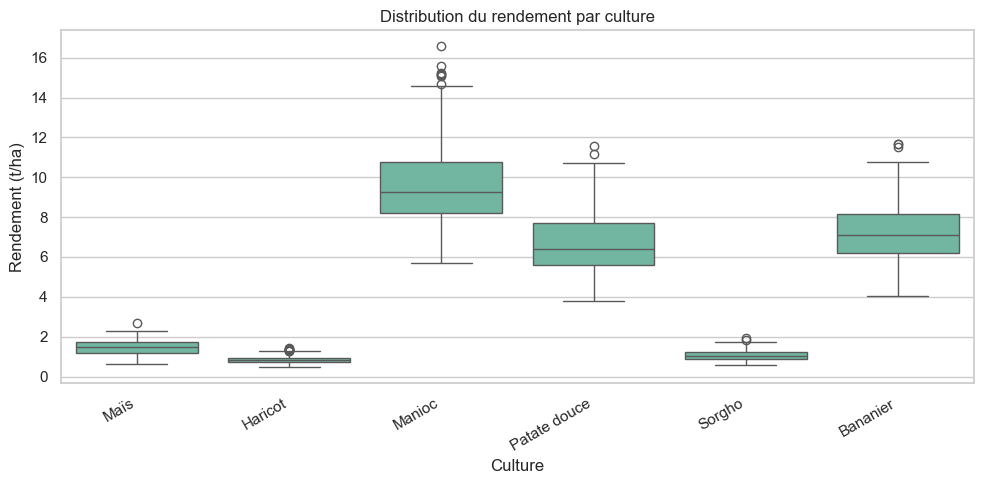

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='culture', y='rendement_t_ha')
plt.title('Distribution du rendement par culture')
plt.xlabel('Culture')
plt.ylabel('Rendement (t/ha)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


Le boxplot montre que les rendements varient fortement selon la culture. Cette différence est normale : chaque culture a un potentiel agronomique différent et réagit différemment à la pluie, à l'altitude et aux pratiques agricoles.


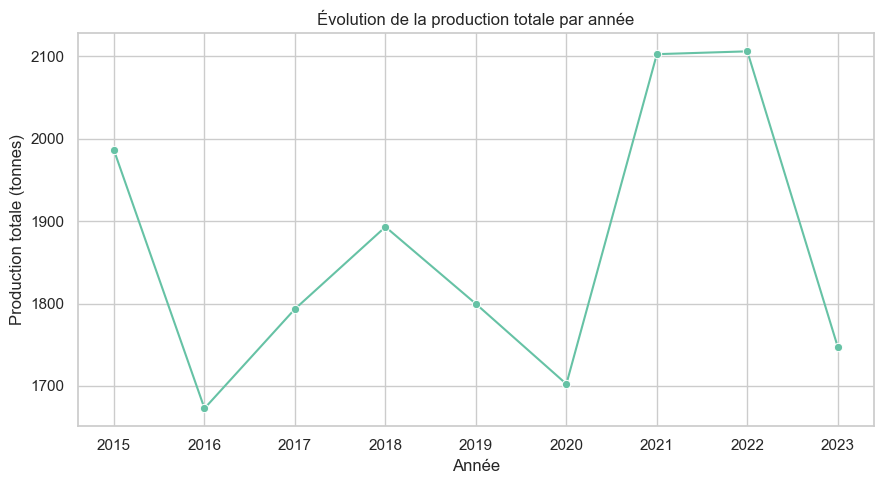

In [9]:
production_par_annee = df_clean.groupby('annee', as_index=False)['production_totale_t'].sum()

plt.figure(figsize=(9, 5))
sns.lineplot(data=production_par_annee, x='annee', y='production_totale_t', marker='o')
plt.title('Évolution de la production totale par année')
plt.xlabel('Année')
plt.ylabel('Production totale (tonnes)')
plt.tight_layout()
plt.show()


La courbe annuelle permet de repérer les tendances globales et les années atypiques. Une baisse peut correspondre à des conditions climatiques défavorables ou à des rendements plus faibles sur plusieurs cultures.


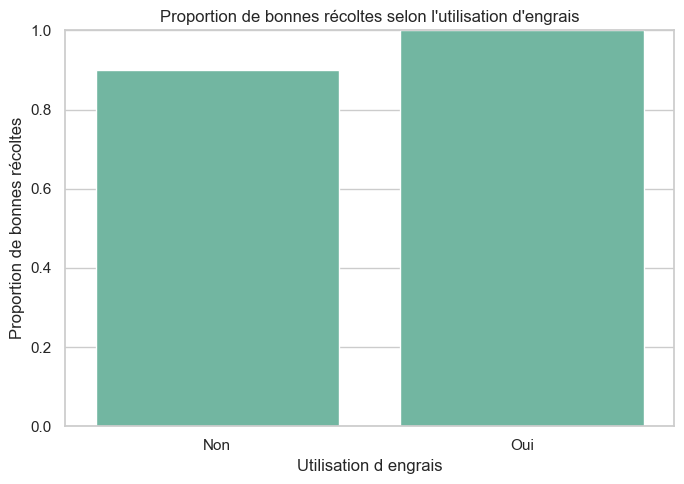

In [10]:
engrais_recolte = df_clean.groupby('utilisation_engrais', as_index=False)['bonne_recolte'].mean()
engrais_recolte['utilisation_engrais'] = engrais_recolte['utilisation_engrais'].map({0.0: 'Non', 1.0: 'Oui'})

plt.figure(figsize=(7, 5))
sns.barplot(data=engrais_recolte, x='utilisation_engrais', y='bonne_recolte')
plt.title("Proportion de bonnes récoltes selon l'utilisation d'engrais")
plt.xlabel('Utilisation d engrais')
plt.ylabel('Proportion de bonnes récoltes')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Le barplot compare directement les parcelles avec et sans engrais. Si la proportion de bonnes récoltes est plus élevée avec engrais, cela soutient l'idée que la fertilisation contribue à améliorer les résultats agricoles, même si cette relation devra être confirmée par les modèles.


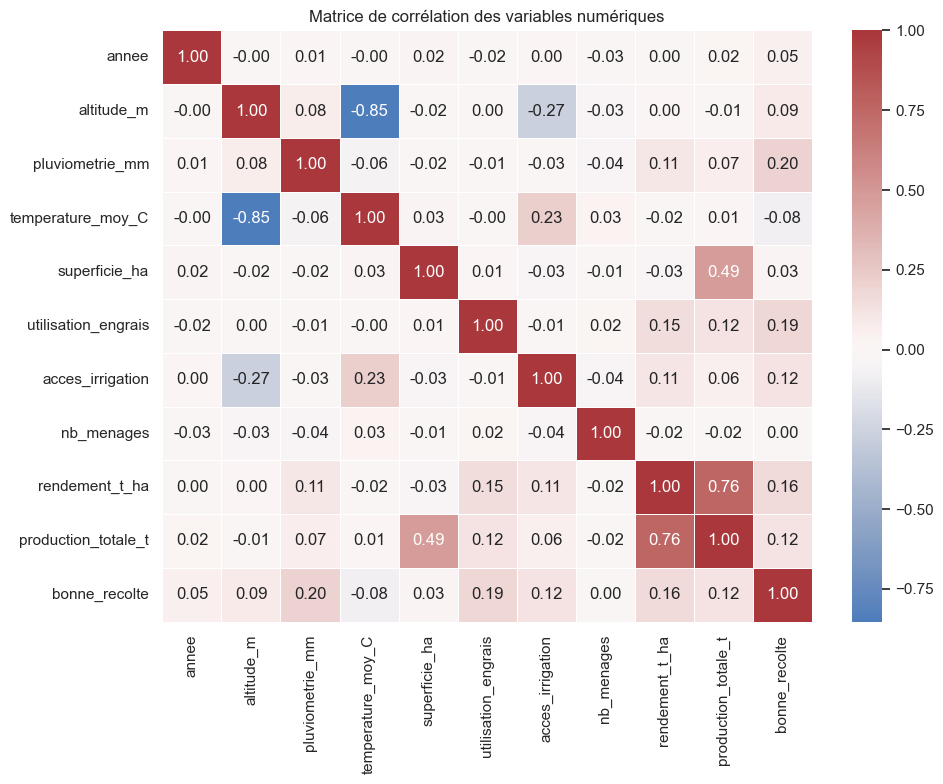

In [11]:
plt.figure(figsize=(10, 8))
corr = df_clean.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()


La matrice de corrélation met en évidence les relations linéaires entre variables numériques. `rendement_t_ha`, `production_totale_t` et `bonne_recolte` sont particuliérement sensibles pour la modélisation, car le rendement et la production sont directement liés à la définition de la cible : les garder comme features provoquerait une fuite de données.


## Exercice 2 — Prétraitement et Préparation des Données

Cette deuxième partie transforme les données propres en matrices compatibles avec les algorithmes de Machine Learning : encodage, séparation X/y, normalisation et split train/test.


### Q8 — Variables catégorielles et choix d'encodage

On identifie les variables catégorielles, puis on compare rapidement `LabelEncoder` et le One-Hot Encoding.


In [12]:
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns.tolist()
print("Variables catégorielles:", categorical_cols)

label_demo = df_clean[['province', 'culture', 'saison']].copy()
for col in categorical_cols:
    label_demo[col + '_label'] = LabelEncoder().fit_transform(label_demo[col])

one_hot_demo = pd.get_dummies(df_clean[categorical_cols], drop_first=True)

print("Exemple LabelEncoder:")
display(label_demo.head())
print("Exemple One-Hot Encoding:")
display(one_hot_demo.head())
print(f"Nombre de colonnes One-Hot avec drop_first=True: {one_hot_demo.shape[1]}")


Variables catégorielles: ['saison', 'province', 'culture']
Exemple LabelEncoder:


,province,culture,saison,saison_label,province_label,culture_label
0,Bujumbura Rural,Maïs,A,0,1,3
1,Bujumbura Rural,Haricot,A,0,1,1
2,Bujumbura Rural,Manioc,A,0,1,2
3,Bujumbura Rural,Patate douce,A,0,1,4
4,Bujumbura Rural,Sorgho,A,0,1,5


Exemple One-Hot Encoding:


,saison_B,province_Bujumbura Rural,province_Bururi,province_Cankuzo,province_Cibitoke,province_Gitega,province_Kayanza,province_Kirundo,province_Makamba,province_Muramvya,province_Muyinga,province_Mwaro,province_Ngozi,province_Rutana,province_Ruyigi,culture_Haricot,culture_Manioc,culture_Maïs,culture_Patate douce,culture_Sorgho
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


Nombre de colonnes One-Hot avec drop_first=True: 20


Les variables catégorielles sont `saison`, `province` et `culture`. On ne peut pas les utiliser directement dans la plupart des modèles scikit-learn, car les algorithmes attendent des valeurs numériques. `LabelEncoder` remplace chaque catégorie par un entier, mais cela crée un ordre artificiel entre les provinces ou les cultures. Le One-Hot Encoding crée une colonne binaire par modalité, ce qui est plus adapté ici pour `province`, `culture` et `saison`. Avec `drop_first=True`, on évite aussi la dummy variable trap, surtout utile pour la régression logistique.


### Q9 — Encodage des variables catégorielles

On applique l'encodage choisi avec la fonction `encode_categoricals()` et on conserve la liste finale des colonnes de features pour garantir la cohérence en inférence.


In [13]:
df_encoded, feature_columns = encode_categoricals(df_clean)

print(f"Nombre de colonnes avant encodage: {df_clean.shape[1]}")
print(f"Nombre de colonnes après encodage: {df_encoded.shape[1]}")
print(f"Nombre de colonnes de features: {len(feature_columns)}")
print("Colonnes encodées:")
print(df_encoded.columns.tolist())


Nombre de colonnes avant encodage: 14
Nombre de colonnes après encodage: 31
Nombre de colonnes de features: 28
Colonnes encodées:
['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages', 'rendement_t_ha', 'production_totale_t', 'bonne_recolte', 'province_Bujumbura Rural', 'province_Bururi', 'province_Cankuzo', 'province_Cibitoke', 'province_Gitega', 'province_Kayanza', 'province_Kirundo', 'province_Makamba', 'province_Muramvya', 'province_Muyinga', 'province_Mwaro', 'province_Ngozi', 'province_Rutana', 'province_Ruyigi', 'culture_Haricot', 'culture_Manioc', 'culture_Maïs', 'culture_Patate douce', 'culture_Sorgho', 'saison_B']


Après encodage, les catégories sont représentées par des indicateurs binaires. La liste `feature_columns` est importante pour la suite du projet : elle permettra de forcer exactement le même ordre et les mêmes colonnes lors des prédictions dans le notebook final et dans l'application Streamlit.


### Q10 — Définition de X et y

On sépare les variables explicatives et la cible en excluant les colonnes qui provoqueraient une fuite de données.


In [14]:
X, y = get_X_y(df_encoded)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Colonnes exclues de X: rendement_t_ha, production_totale_t, bonne_recolte")
display(X.head())
display(y.head())


X shape: (1576, 28)
y shape: (1576,)
Colonnes exclues de X: rendement_t_ha, production_totale_t, bonne_recolte


,annee,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages,province_Bujumbura Rural,province_Bururi,...,province_Mwaro,province_Ngozi,province_Rutana,province_Ruyigi,culture_Haricot,culture_Manioc,culture_Maïs,culture_Patate douce,culture_Sorgho,saison_B
0,2015,881,829.9,23.9,1.33,1.0,1,154,True,False,...,False,False,False,False,False,False,True,False,False,False
1,2015,803,955.4,22.1,3.25,0.0,0,16,True,False,...,False,False,False,False,True,False,False,False,False,False
2,2015,835,1060.3,24.9,1.71,1.0,1,103,True,False,...,False,False,False,False,False,True,False,False,False,False
3,2015,848,760.3,23.8,2.94,0.0,1,64,True,False,...,False,False,False,False,False,False,False,True,False,False
4,2015,837,1126.8,23.1,3.94,0.0,0,56,True,False,...,False,False,False,False,False,False,False,False,True,False


0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: bonne_recolte, dtype: float64

La cible est `bonne_recolte`. Les colonnes `rendement_t_ha` et `production_totale_t` sont exclues, car elles sont directement liées à la définition de la bonne récolte. Les inclure donnerait au modèle une information disponible après la récolte, ce qui créerait du data leakage et produirait des scores artificiellement élevés.


### Q11 — Normalisation des variables numériques

On sépare d'abord train/test, puis on applique le `StandardScaler` uniquement aux variables numériques continues. Les colonnes binaires et One-Hot restent en 0/1.


In [15]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_test_scaled, scaler = normalize_features(X_train, X_test)

continuous_cols = _continuous_numerical_columns(X_train)
print("Colonnes numériques normalisées:", continuous_cols)

scaled_stats = pd.DataFrame({
    'mean_after_scaling': X_train_scaled[continuous_cols].mean(),
    'std_after_scaling': X_train_scaled[continuous_cols].std(ddof=0),
})
display(scaled_stats)


Colonnes numériques normalisées: ['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'nb_menages']


,mean_after_scaling,std_after_scaling
annee,-1.153222e-14,1.0
altitude_m,8.740803e-17,1.0
pluviometrie_mm,-7.655252e-16,1.0
temperature_moy_C,6.231347e-16,1.0
superficie_ha,-3.355341e-16,1.0
nb_menages,6.203151e-17,1.0


La normalisation est essentielle pour la régression logistique, car les coefficients et l'optimisation sont sensibles aux échelles des variables. Elle est moins critique pour les arbres de décision et les forêts aléatoires, qui découpent les variables par seuils. Après normalisation sur le train, les variables continues ont une moyenne proche de 0 et un écart-type proche de 1.


### Q12 — Division train/test stratifiée

On vérifie que la stratification conserve des proportions similaires de bonnes et mauvaises récoltes dans les ensembles d'entraînement et de test.


In [16]:
train_props = y_train.value_counts(normalize=True).sort_index() * 100
test_props = y_test.value_counts(normalize=True).sort_index() * 100

print("Proportions y_train (%):")
display(train_props)
print("Proportions y_test (%):")
display(test_props)

print("Fichiers sauvegardés dans artifacts/:")
for file_name in ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]:
    print(PROJECT_ROOT / "artifacts" / file_name)


Proportions y_train (%):


bonne_recolte
0.0     6.666667
1.0    93.333333
Name: proportion, dtype: float64

Proportions y_test (%):


bonne_recolte
0.0     6.64557
1.0    93.35443
Name: proportion, dtype: float64

Fichiers sauvegardés dans artifacts/:
C:\Users\migue\agri-burundi-ml\artifacts\X_train.csv
C:\Users\migue\agri-burundi-ml\artifacts\X_test.csv
C:\Users\migue\agri-burundi-ml\artifacts\y_train.csv
C:\Users\migue\agri-burundi-ml\artifacts\y_test.csv


L'option `stratify=y` est importante car la cible est déséquilibrée. Elle évite d'obtenir un jeu de test avec une proportion de mauvaises récoltes trop différente du train. Le paramètre `random_state=42` rend la division reproductible : sans lui, les lignes changeraient à chaque exécution et les métriques futures ne seraient pas directement comparables.


## Résumé final de la phase

On affiche les dimensions finales et les distributions de classes. La phase s'arrête ici : aucun modèle n'est entraîné dans ce notebook.


In [17]:
print(f"Final dataset shape after preprocessing: {df_encoded.shape}")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print("Class distribution in y_train:")
print(y_train.value_counts().sort_index())
print("Class distribution in y_test:")
print(y_test.value_counts().sort_index())


Final dataset shape after preprocessing: (1576, 31)
X_train shape: (1260, 28)
X_test shape: (316, 28)
Class distribution in y_train:
bonne_recolte
0.0      84
1.0    1176
Name: count, dtype: int64
Class distribution in y_test:
bonne_recolte
0.0     21
1.0    295
Name: count, dtype: int64


## Exercice 3 — Arbre de Décision : entraînement, interprétation et surapprentissage

On entraîne maintenant un arbre de décision, puis on analyse ses erreurs, ses règles et l'effet de la profondeur maximale. Cette section commence la modélisation, en utilisant les jeux de données préparés dans l'exercice 2.


In [18]:
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib

from src.train import (
    train_decision_tree,
    train_random_forest,
    train_logistic_regression,
    train_and_save_all,
)
from src.evaluate import (
    get_metrics,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_roc_curves,
    cross_validate_model,
    overfitting_analysis,
    save_metrics,
)
print('Modules de modélisation chargés.')


Modules de modélisation chargés.


### Q13 — Entraînement de l'arbre de décision

On entraîne un arbre de décision avec `max_depth=4` et `criterion='gini'`, puis on affiche l'accuracy et le rapport de classification complet.


In [19]:
decision_tree = train_decision_tree(X_train_scaled, y_train, max_depth=4, criterion='gini')
dt_metrics = get_metrics(decision_tree, X_test_scaled, y_test)
dt_report = classification_report(y_test, decision_tree.predict(X_test_scaled), zero_division=0)

print(f"Decision Tree accuracy: {dt_metrics['accuracy']:.4f}")
print(dt_report)


Decision Tree accuracy: 0.8987
              precision    recall  f1-score   support

         0.0       0.26      0.29      0.27        21
         1.0       0.95      0.94      0.95       295

    accuracy                           0.90       316
   macro avg       0.60      0.61      0.61       316
weighted avg       0.90      0.90      0.90       316



L'arbre de décision obtient une accuracy d'environ **0,899**. Le rapport montre une très bonne performance sur la classe majoritaire `1` (bonne récolte), mais une performance beaucoup plus faible sur la classe `0` (mauvaise récolte). Cela confirme l'effet du déséquilibre observé en Q6 : le modèle apprend surtout à reconnaêtre les bonnes récoltes.


### Q14 — Matrice de confusion

On visualise la matrice de confusion pour compter les erreurs du modèle.


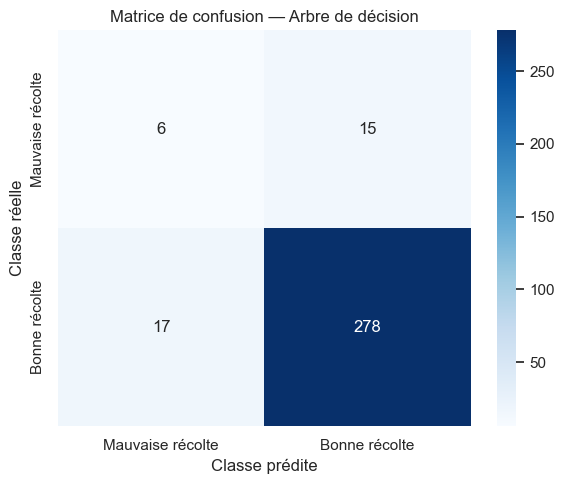

Matrice de confusion [[TN, FP], [FN, TP]]:
[[  6  15]
 [ 17 278]]
Faux positifs (classe positive = bonne récolte): 15
Faux négatifs (classe positive = bonne récolte): 17
Mauvaises récoltes manquées, c.-à-d. mauvaises prédites bonnes: 15


In [20]:
plot_confusion_matrix(decision_tree, X_test_scaled, y_test, "Matrice de confusion — Arbre de décision")

dt_cm = dt_metrics['confusion_matrix']
tn, fp, fn, tp = dt_cm.ravel()
print("Matrice de confusion [[TN, FP], [FN, TP]]:")
print(dt_cm)
print(f"Faux positifs (classe positive = bonne récolte): {fp}")
print(f"Faux négatifs (classe positive = bonne récolte): {fn}")
print(f"Mauvaises récoltes manquées, c.-à-d. mauvaises prédites bonnes: {fp}")


Avec la convention scikit-learn oà la classe positive est `1` (bonne récolte), l'arbre produit **15 faux positifs** et **17 faux négatifs**. Agronomiquement, l'erreur la plus coûteuse est surtout de prédire une bonne récolte alors que la récolte sera mauvaise : l'agriculteur ne reçoit pas d'alerte et peut ne pas prendre de mesures préventives. Dans cette matrice, cela correspond aux **15 mauvaises récoltes prédites bonnes**.


### Q15 — Visualisation de l'arbre

On affiche la structure de l'arbre et on identifie la variable utilisée à la racine.


Variable du premier split: pluviometrie_mm
Seuil normalisé du premier split: -0.9650


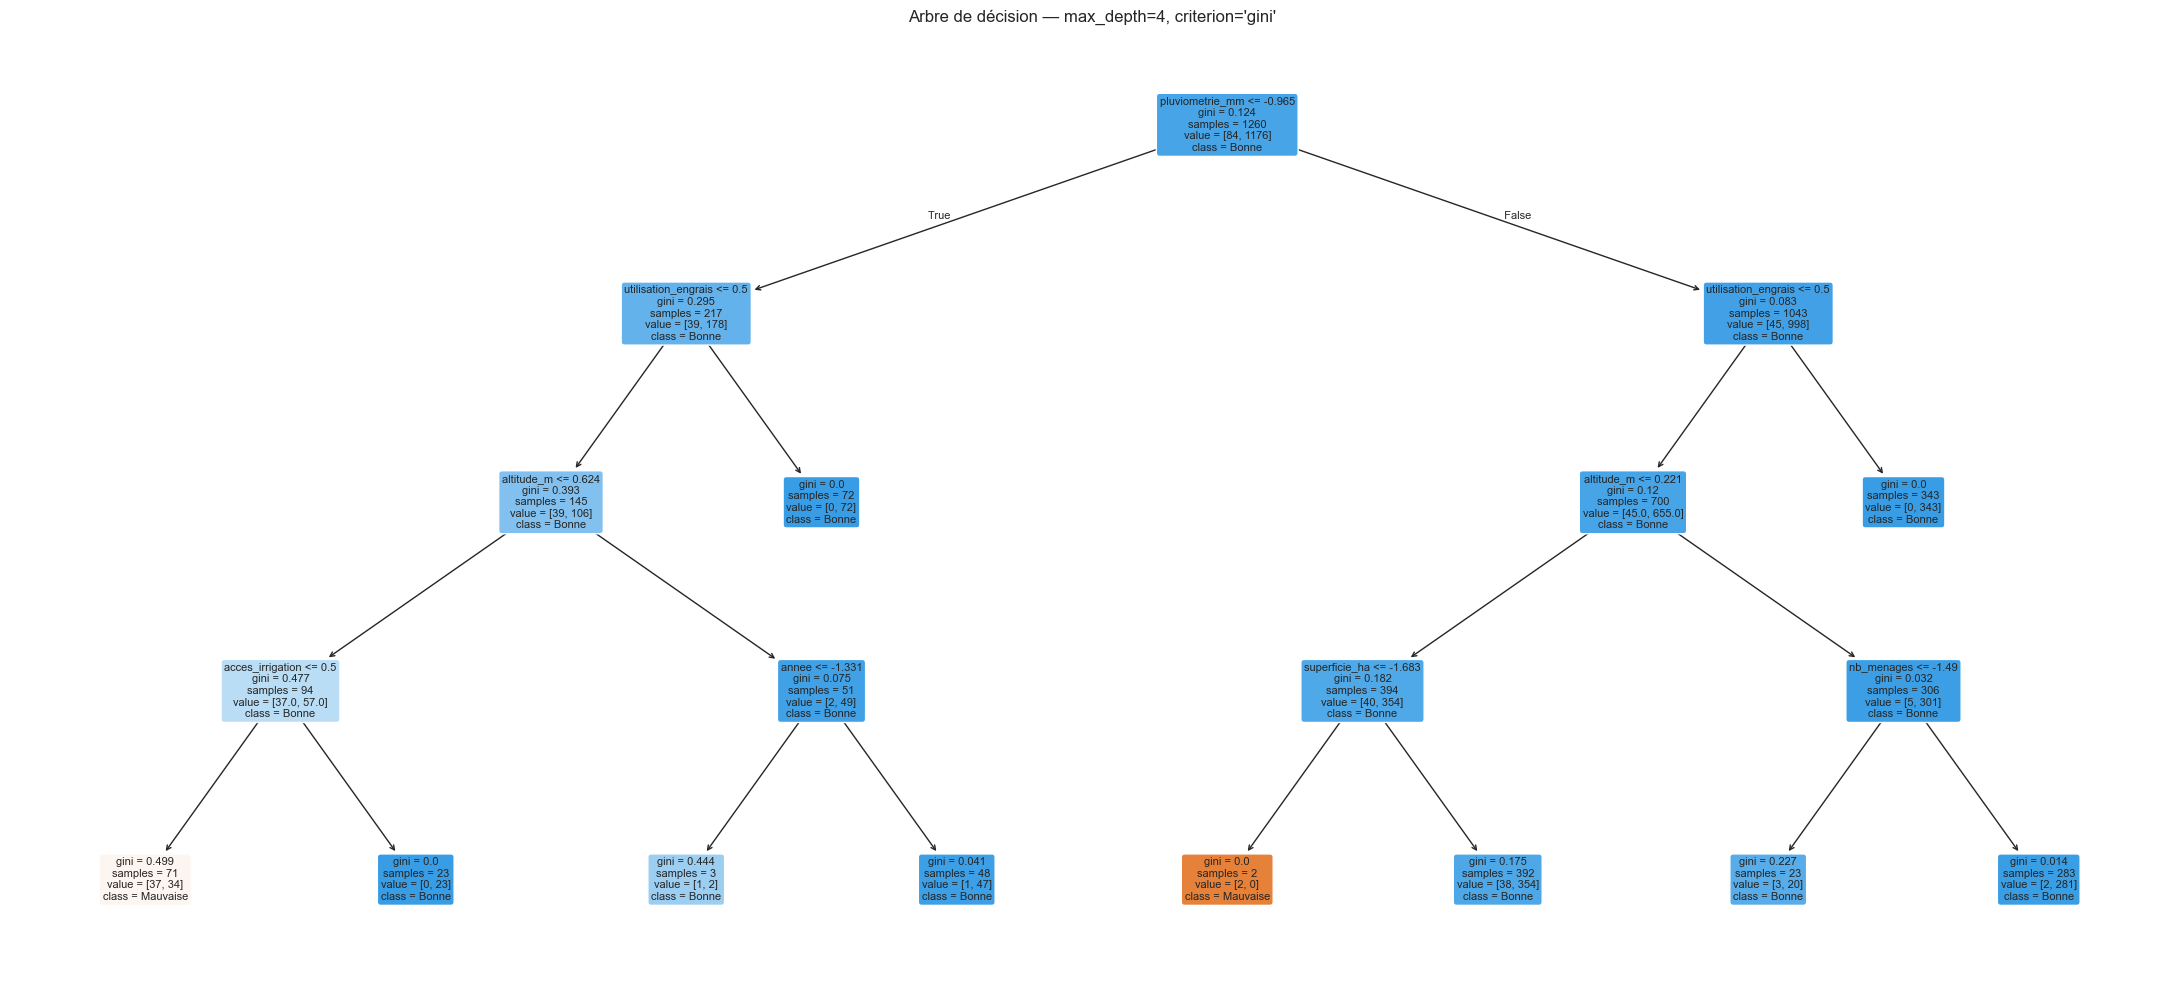

In [21]:
root_feature_index = decision_tree.tree_.feature[0]
root_feature = X_train_scaled.columns[root_feature_index]
root_threshold = decision_tree.tree_.threshold[0]

print(f"Variable du premier split: {root_feature}")
print(f"Seuil normalisé du premier split: {root_threshold:.4f}")

plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=X_train_scaled.columns,
    class_names=['Mauvaise', 'Bonne'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Arbre de décision — max_depth=4, criterion='gini'")
plt.tight_layout()
plt.show()


La première séparation se fait sur **`pluviometrie_mm`** avec un seuil normalisé d'environ **-0,965**. Comme la variable a été standardisée, ce seuil signifie une pluviométrie nettement inférieure à la moyenne du jeu d'entraînement. Agronomiquement, c'est cohérent : l'eau disponible pendant la saison est un facteur déterminant pour la croissance des cultures et la probabilité d'une bonne récolte.


### Q16 — Importance des variables de l'arbre

On affiche les variables les plus importantes pour l'arbre de décision.


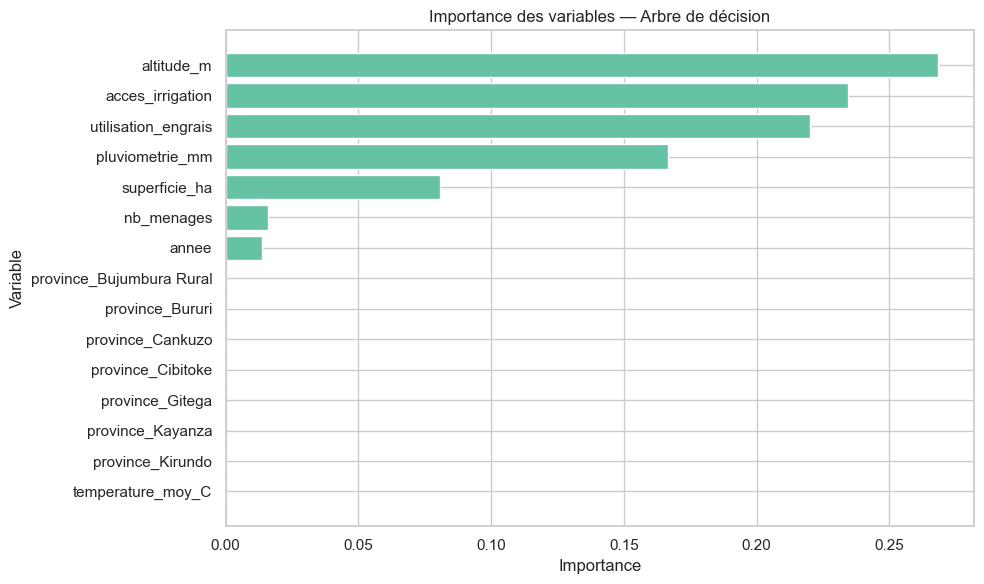

Top 10 variables — Arbre de décision:


altitude_m                  0.268441
acces_irrigation            0.234428
utilisation_engrais         0.220213
pluviometrie_mm             0.166496
superficie_ha               0.080634
nb_menages                  0.016086
annee                       0.013701
temperature_moy_C           0.000000
province_Bujumbura Rural    0.000000
province_Bururi             0.000000
dtype: float64

In [22]:
plot_feature_importance(
    decision_tree,
    X_train_scaled.columns.tolist(),
    "Importance des variables — Arbre de décision",
    top_n=15,
)

dt_importances = pd.Series(decision_tree.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 10 variables — Arbre de décision:")
display(dt_importances.head(10))


Les principales variables de l'arbre sont **`altitude_m`**, **`acces_irrigation`**, **`utilisation_engrais`**, **`pluviometrie_mm`** et **`superficie_ha`**. Ce classement est cohérent avec l'intuition agronomique : altitude, eau et fertilisation influencent directement le rendement. L'importance de `utilisation_engrais` envoie un message clair aux décideurs : l'accès aux intrants agricoles peut être un levier concret pour améliorer les récoltes.


### Q17 — Analyse du surapprentissage

On entraîne des arbres de profondeur 1 à 20 et on compare l'accuracy train et test.


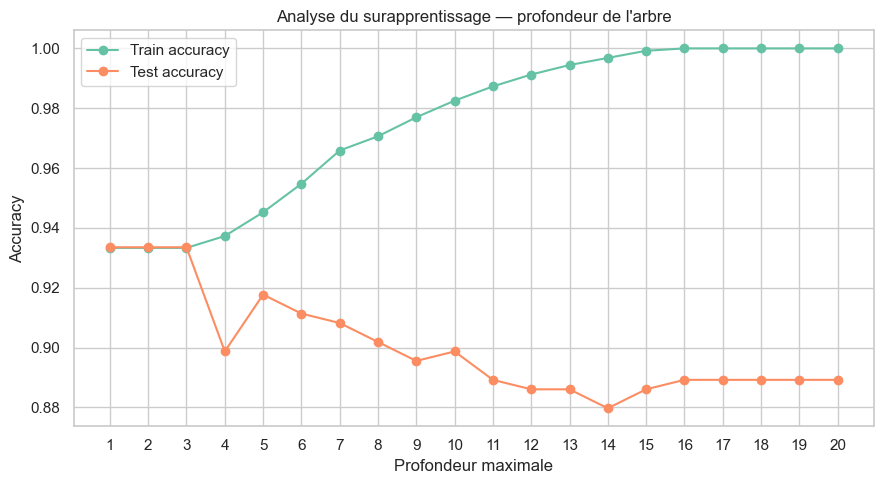

,depths,train_scores,test_scores
0,1,0.933333,0.933544
1,2,0.933333,0.933544
2,3,0.933333,0.933544
3,4,0.937302,0.898734
4,5,0.945238,0.917722
5,6,0.954762,0.911392
6,7,0.965873,0.908228
7,8,0.970635,0.901899
8,9,0.976984,0.895570
9,10,0.982540,0.898734


Meilleure profondeur selon le test: 1
Meilleure accuracy test: 0.9335


In [23]:
overfit_results = overfitting_analysis(X_train_scaled, y_train, X_test_scaled, y_test, max_depths=range(1, 21))

plt.figure(figsize=(9, 5))
plt.plot(overfit_results['depths'], overfit_results['train_scores'], marker='o', label='Train accuracy')
plt.plot(overfit_results['depths'], overfit_results['test_scores'], marker='o', label='Test accuracy')
plt.title("Analyse du surapprentissage — profondeur de l'arbre")
plt.xlabel("Profondeur maximale")
plt.ylabel("Accuracy")
plt.xticks(overfit_results['depths'])
plt.legend()
plt.tight_layout()
plt.show()

overfit_df = pd.DataFrame(overfit_results)
display(overfit_df)

best_depth = overfit_df.loc[overfit_df['test_scores'].idxmax(), 'depths']
best_test_score = overfit_df['test_scores'].max()
print(f"Meilleure profondeur selon le test: {best_depth}")
print(f"Meilleure accuracy test: {best_test_score:.4f}")


Dans cette exécution, la meilleure accuracy test est obtenue avec une profondeur très faible, **1** à **3** donnant environ **0,934**. à partir de la profondeur **4**, l'accuracy train augmente alors que l'accuracy test baisse : le surapprentissage commence donc clairement autour de **max_depth=4**. Dans un contexte agricole, cela signifie que l'arbre apprend des particularités historiques du dataset plutôt que des règles générales valables pour de nouvelles saisons ou provinces.


## Exercice 4 — Forêt Aléatoire : robustesse et comparaison

On entraîne une forêt aléatoire de 100 arbres, on la compare à l'arbre de décision, puis on étudie sa stabilité par validation croisée et par variation du nombre d'arbres.


### Q18 — Entraînement de la forêt aléatoire

On entraîne une forêt aléatoire avec `n_estimators=100` et on compare son accuracy à celle de l'arbre.


In [24]:
random_forest = train_random_forest(X_train_scaled, y_train, n_estimators=100, random_state=42)
rf_metrics = get_metrics(random_forest, X_test_scaled, y_test)

accuracy_diff = rf_metrics['accuracy'] - dt_metrics['accuracy']
print(f"Decision Tree accuracy: {dt_metrics['accuracy']:.4f}")
print(f"Random Forest accuracy: {rf_metrics['accuracy']:.4f}")
print(f"Différence Random Forest - Decision Tree: {accuracy_diff:.4f}")


Decision Tree accuracy: 0.8987
Random Forest accuracy: 0.9304
Différence Random Forest - Decision Tree: 0.0316


La forêt aléatoire obtient une accuracy d'environ **0,930**, contre **0,899** pour l'arbre de profondeur 4. Elle est donc meilleure d'environ **3,16 points de pourcentage** sur ce jeu de test. Cette amélioration vient du fait qu'elle agrège plusieurs arbres au lieu de dépendre d'une seule structure de décision.


### Q19 — Pourquoi une forêt peut mieux généraliser


In [25]:
print("Une forêt aléatoire combine plusieurs arbres entraînés sur des échantillons bootstrap.")


Une forêt aléatoire combine plusieurs arbres entraînés sur des échantillons bootstrap.


Le **bagging** consiste à entraîner plusieurs arbres sur des échantillons tirés avec remise, puis à agréger leurs prédictions. Cela réduit la variance par rapport à un arbre unique. Le paramètre `max_features` force chaque split à ne considérer qu'une partie des variables, ce qui rend les arbres moins corrélés entre eux. Une forêt aléatoire peut tout de même surapprendre, surtout si les arbres sont très profonds, si le dataset est petit ou si les variables contiennent du bruit et des fuites d'information.


### Q20 — Validation croisée à 5 folds

On évalue la forêt aléatoire avec une validation croisée à 5 folds.


In [26]:
rf_cv = cross_validate_model(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
)

print("Scores CV:", rf_cv['all_scores'])
print(f"Accuracy CV moyenne ± écart-type: {rf_cv['mean_accuracy']:.4f} ± {rf_cv['std_accuracy']:.4f}")
print(f"Accuracy test simple: {rf_metrics['accuracy']:.4f}")


Scores CV: [0.92857143 0.93650794 0.93253968 0.93253968 0.94047619]
Accuracy CV moyenne ± écart-type: 0.9341 ± 0.0040
Accuracy test simple: 0.9304


La validation croisée donne une accuracy moyenne d'environ **0,934 ± 0,004**, très proche de l'accuracy simple du test (**0,930**). La validation croisée est plus fiable qu'un seul split, car elle évalue le modèle sur plusieurs découpages des données et réduit le risque de conclure à partir d'un jeu de test particuliérement favorable ou défavorable.


### Q21 — Importance des variables de la forêt aléatoire

On affiche les variables les plus importantes pour la forêt et on compare le top-5 avec celui de l'arbre.


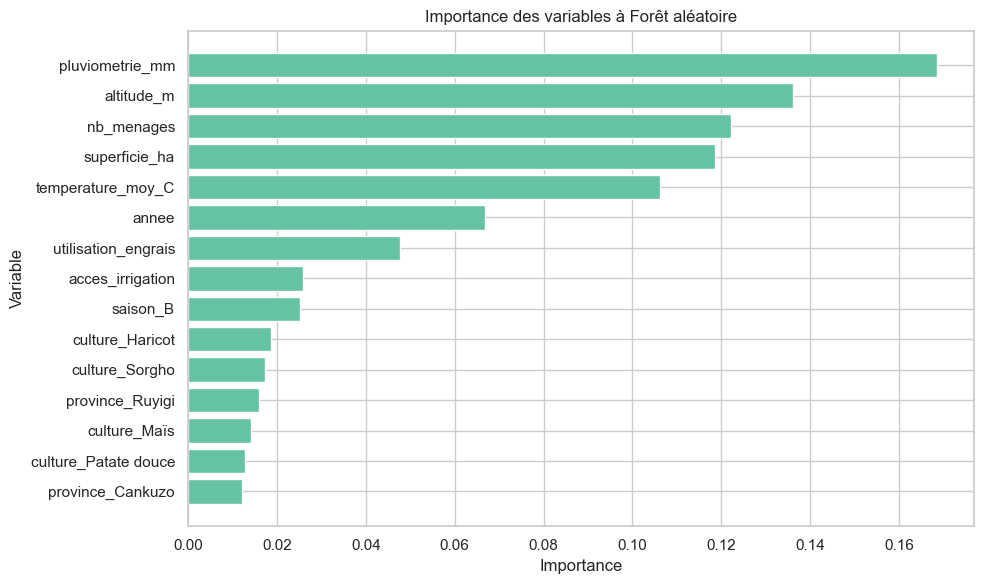

Top 5 arbre de décision:


altitude_m             0.268441
acces_irrigation       0.234428
utilisation_engrais    0.220213
pluviometrie_mm        0.166496
superficie_ha          0.080634
dtype: float64

Top 5 forêt aléatoire:


pluviometrie_mm      0.168494
altitude_m           0.136179
nb_menages           0.122259
superficie_ha        0.118666
temperature_moy_C    0.106247
dtype: float64

In [27]:
plot_feature_importance(
    random_forest,
    X_train_scaled.columns.tolist(),
    "Importance des variables à Forêt aléatoire",
    top_n=15,
)

rf_importances = pd.Series(random_forest.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 5 arbre de décision:")
display(dt_importances.head(5))
print("Top 5 forêt aléatoire:")
display(rf_importances.head(5))


Le top-5 de la forêt met surtout en avant **`pluviometrie_mm`**, **`altitude_m`**, **`nb_menages`**, **`superficie_ha`** et **`temperature_moy_C`**. Il partage avec l'arbre l'importance de l'altitude, de la pluie et de la superficie, mais il répartit davantage l'importance entre plusieurs variables continues. C'est attendu : la forêt moyenne de nombreux arbres et donne souvent une vision moins dépendante d'un seul chemin de décision.


### Q22 — Impact du nombre d'arbres

On fait varier `n_estimators` de 10 à 500 par pas de 10 et on observe l'accuracy test.


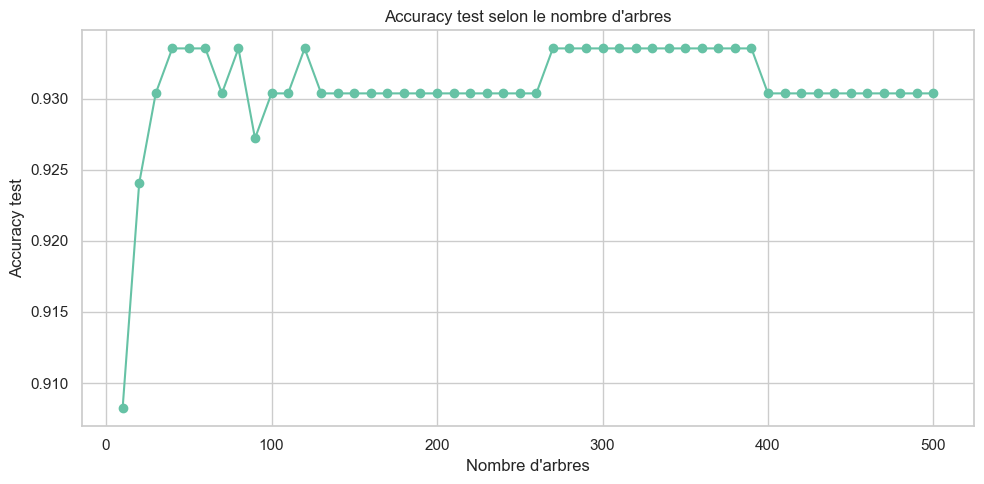

,n_estimators,test_accuracy
0,10,0.908228
1,20,0.924051
2,30,0.930380
3,40,0.933544
4,50,0.933544
5,60,0.933544
6,70,0.930380
7,80,0.933544
8,90,0.927215
9,100,0.930380


Meilleur résultat:


n_estimators     40.000000
test_accuracy     0.933544
Name: 3, dtype: float64

In [28]:
n_estimators_values = list(range(10, 501, 10))
rf_estimator_scores = []

for n_estimators in n_estimators_values:
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train_scaled, y_train)
    rf_estimator_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_values, rf_estimator_scores, marker='o')
plt.title("Accuracy test selon le nombre d'arbres")
plt.xlabel("Nombre d'arbres")
plt.ylabel("Accuracy test")
plt.tight_layout()
plt.show()

rf_estimators_df = pd.DataFrame({'n_estimators': n_estimators_values, 'test_accuracy': rf_estimator_scores})
display(rf_estimators_df)
print("Meilleur résultat:")
display(rf_estimators_df.loc[rf_estimators_df['test_accuracy'].idxmax()])


La performance se stabilise rapidement autour de **40 à 100 arbres**, puis reste très proche de **0,930** jusqu'à 500 arbres. Ajouter plus d'arbres rend le modèle plus coûteux à entraîner et à charger, mais n'apporte presque plus de gain mesurable ici. Un compromis raisonnable est donc de garder **100 arbres**, comme demandé dans l'exercice.


## Exercice 5 — Régression Logistique : interprétation et courbes ROC

On entraîne une régression logistique, on interprète ses coefficients, puis on compare les trois modèles avec accuracy, F1 et AUC.


### Q23 — Entraînement et coefficients de la régression logistique

On entraîne la régression logistique et on affiche les coefficients les plus positifs et les plus négatifs.


In [29]:
logistic_regression = train_logistic_regression(X_train_scaled, y_train, max_iter=1000, random_state=42)
lr_metrics = get_metrics(logistic_regression, X_test_scaled, y_test)

lr_coefficients = pd.Series(logistic_regression.coef_[0], index=X_train_scaled.columns).sort_values(ascending=False)
print(f"Logistic Regression accuracy: {lr_metrics['accuracy']:.4f}")
print("Coefficients les plus positifs:")
display(lr_coefficients.head(10))
print("Coefficients les plus négatifs:")
display(lr_coefficients.tail(10))


Logistic Regression accuracy: 0.9399
Coefficients les plus positifs:


utilisation_engrais         2.972350
acces_irrigation            2.587341
province_Gitega             1.097343
pluviometrie_mm             0.924012
altitude_m                  0.619222
province_Kayanza            0.560465
province_Bururi             0.534917
province_Cibitoke           0.417850
province_Bujumbura Rural    0.299211
superficie_ha               0.262699
dtype: float64

Coefficients les plus négatifs:


temperature_moy_C   -0.192108
province_Muyinga    -0.254616
culture_Haricot     -0.259522
culture_Maïs        -0.368789
province_Kirundo    -0.388930
culture_Sorgho      -0.457688
saison_B            -0.461942
province_Ngozi      -0.508169
province_Cankuzo    -0.790578
province_Ruyigi     -0.822704
dtype: float64

Les coefficients positifs les plus forts sont **`utilisation_engrais`**, **`acces_irrigation`**, **`province_Gitega`**, **`pluviometrie_mm`** et **`altitude_m`**. Ils indiquent que ces facteurs augmentent la probabilité estimée d'une bonne récolte. Les coefficients négatifs incluent notamment **`province_Ruyigi`**, **`province_Cankuzo`**, **`province_Ngozi`**, **`saison_B`** et certaines cultures comme **sorgho** ou **maïs** dans ce codage. Ces effets sont plausibles comme associations statistiques, mais ils doivent être interprétés avec prudence : les coefficients des variables One-Hot sont relatifs aux catégories de référence supprimées par `drop_first=True`.


### Q24 — Comparaison des accuracies

On compare la régression logistique avec l'arbre de décision et la forêt aléatoire.


In [30]:
accuracy_comparison = pd.DataFrame({
    'model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'accuracy': [dt_metrics['accuracy'], rf_metrics['accuracy'], lr_metrics['accuracy']],
    'f1_weighted': [dt_metrics['f1'], rf_metrics['f1'], lr_metrics['f1']],
})
display(accuracy_comparison.sort_values('accuracy', ascending=False))


,model,accuracy,f1_weighted
2,Logistic Regression,0.939873,0.920272
1,Random Forest,0.930380,0.899875
0,Decision Tree,0.898734,0.900863


Dans cette exécution, la régression logistique obtient la meilleure accuracy, environ **0,940**, devant la forêt aléatoire (**0,930**) et l'arbre de décision (**0,899**). L'hypothèse de linéarité est une simplification forte pour des données agricoles, car les effets de la pluie, de la température et de l'altitude peuvent être non linéaires. Cependant, sur ce dataset précis, les variables disponibles semblent contenir un signal assez bien capturé par une frontière linéaire.


### Q25 — Courbes ROC et AUC

On trace les courbes ROC des trois modèles et on calcule l'AUC de chacun.


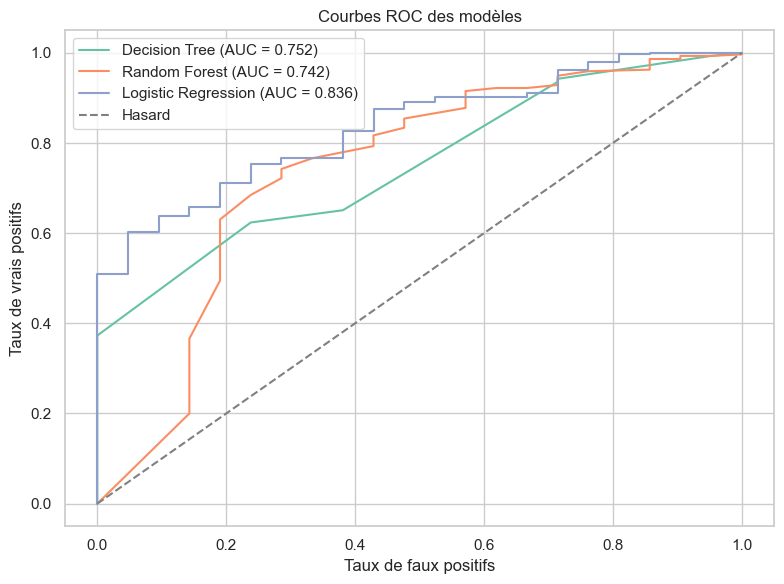

AUC par modèle:
{'Decision Tree': 0.7519774011299435, 'Random Forest': 0.7418886198547217, 'Logistic Regression': 0.8358353510895884}


In [31]:
models_for_roc = {
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'Logistic Regression': logistic_regression,
}
auc_scores = plot_roc_curves(models_for_roc, X_test_scaled, y_test)
print("AUC par modèle:")
print(auc_scores)


La meilleure AUC est obtenue par la **régression logistique** avec environ **0,836**. L'arbre de décision obtient environ **0,752**, et la forêt aléatoire environ **0,742**. Le classement par AUC correspond ici globalement au classement par accuracy pour le meilleur modèle, mais il nuance la forêt : malgrà une bonne accuracy, son AUC reste plus faible, ce qui indique une capacité moins bonne à classer les observations selon leur risque réel sur tous les seuils.


### Q26 — Interprétation de l'AUC


In [32]:
print("AUC scores:")
for model_name, score in auc_scores.items():
    print(f"{model_name}: {score:.4f}")


AUC scores:
Decision Tree: 0.7520
Random Forest: 0.7419
Logistic Regression: 0.8358


L'AUC mesure la capacité d'un modèle à classer une observation positive au-dessus d'une observation négative sur l'ensemble des seuils possibles. Elle est plus informative que l'accuracy lorsque les classes sont déséquilibrées, car l'accuracy peut être élevée simplement en prédisant souvent la classe majoritaire. Oui, un modèle peut avoir **75 % d'accuracy** et une **AUC proche de 0,5** s'il prédit surtout la classe dominante mais ne discrimine pas réellement les risques. Pour la prédiction agricole, il faut regarder les deux, mais l'AUC et le rappel des mauvaises récoltes sont particuliérement importants : manquer une mauvaise récolte peut coùter plus cher qu'une alerte prudente.


## Sauvegarde des modèles et résumé final

On sauvegarde les trois modèles, le scaler, les colonnes de features, puis `metrics.json`. On termine par un tableau comparatif.


In [33]:
trained_models = train_and_save_all(X_train_scaled, y_train, scaler, feature_columns)

dt_cv = cross_validate_model(
    DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
)
lr_cv = cross_validate_model(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
)

compact_metrics = {
    'decision_tree': {
        'accuracy': dt_metrics['accuracy'],
        'f1': dt_metrics['f1'],
        'auc': auc_scores['Decision Tree'],
    },
    'random_forest': {
        'accuracy': rf_metrics['accuracy'],
        'f1': rf_metrics['f1'],
        'auc': auc_scores['Random Forest'],
    },
    'logistic_regression': {
        'accuracy': lr_metrics['accuracy'],
        'f1': lr_metrics['f1'],
        'auc': auc_scores['Logistic Regression'],
    },
}
save_metrics(compact_metrics, path='metrics.json')

summary_table = pd.DataFrame([
    {
        'model': 'Decision Tree',
        'accuracy': dt_metrics['accuracy'],
        'f1_weighted': dt_metrics['f1'],
        'auc': auc_scores['Decision Tree'],
        'cv_mean': dt_cv['mean_accuracy'],
        'cv_std': dt_cv['std_accuracy'],
    },
    {
        'model': 'Random Forest',
        'accuracy': rf_metrics['accuracy'],
        'f1_weighted': rf_metrics['f1'],
        'auc': auc_scores['Random Forest'],
        'cv_mean': rf_cv['mean_accuracy'],
        'cv_std': rf_cv['std_accuracy'],
    },
    {
        'model': 'Logistic Regression',
        'accuracy': lr_metrics['accuracy'],
        'f1_weighted': lr_metrics['f1'],
        'auc': auc_scores['Logistic Regression'],
        'cv_mean': lr_cv['mean_accuracy'],
        'cv_std': lr_cv['std_accuracy'],
    },
])

display(summary_table)
print("metrics.json sauvegardé à la racine du projet.")
print("Modèles sauvegardés dans models/: decision_tree.pkl, random_forest.pkl, logistic_regression.pkl")
print("Artifacts sauvegardés: scaler.pkl, feature_columns.pkl")


,model,accuracy,f1_weighted,auc,cv_mean,cv_std
0,Decision Tree,0.898734,0.900863,0.751977,0.925397,0.014064
1,Random Forest,0.930380,0.899875,0.741889,0.934127,0.004047
2,Logistic Regression,0.939873,0.920272,0.835835,0.937302,0.008474


metrics.json sauvegardé à la racine du projet.
Modèles sauvegardés dans models/: decision_tree.pkl, random_forest.pkl, logistic_regression.pkl
Artifacts sauvegardés: scaler.pkl, feature_columns.pkl


## Exercice 6 — Prédiction sur de nouvelles données réelles

Cette section utilise les modèles déjà sauvegardés dans `models/` pour simuler des prédictions sur quatre scénarios agricoles. Aucun modèle n'est réentraîné : on recharge le scaler, la liste des colonnes et les trois modèles sauvegardés.


### Q27 — Prédictions des quatre scénarios

Les scénarios fournis ne contiennent pas `annee`, `saison`, `superficie_ha` et `nb_menages`, alors que ces variables font partie des features d'entraînement. Pour garder une inférence reproductible sans réentraîner les modèles, on utilise l'année maximale du dataset, la saison A, puis la médiane observée pour `superficie_ha` et `nb_menages` dans le couple province-culture concerné. Ensuite, la transformation passe par `build_inference_input()` afin de respecter exactement les colonnes d'entraînement.


In [34]:
import joblib

from src.preprocess import build_inference_input

loaded_models = {
    'DT': joblib.load(PROJECT_ROOT / 'models' / 'decision_tree.pkl'),
    'RF': joblib.load(PROJECT_ROOT / 'models' / 'random_forest.pkl'),
    'LR': joblib.load(PROJECT_ROOT / 'models' / 'logistic_regression.pkl'),
}
loaded_scaler = joblib.load(PROJECT_ROOT / 'models' / 'scaler.pkl')
loaded_feature_columns = joblib.load(PROJECT_ROOT / 'models' / 'feature_columns.pkl')
loaded_numerical_cols = list(loaded_scaler.feature_names_in_)

maize_dataset_value = [
    culture for culture in df_clean['culture'].unique()
    if str(culture).startswith('Ma') and culture != 'Manioc'
][0]


def canonicalize_culture(culture):
    # Align user-facing culture names with the exact dataset encoding.
    if culture in df_clean['culture'].unique():
        return culture
    if str(culture).startswith('Ma') and culture != 'Manioc':
        return maize_dataset_value
    return culture


def add_missing_scenario_defaults(raw_scenario):
    # Add reproducible defaults for features omitted from the scenario table.
    scenario = raw_scenario.copy()
    scenario['culture'] = canonicalize_culture(scenario['culture'])
    group = df_clean[
        (df_clean['province'] == scenario['province'])
        & (df_clean['culture'] == scenario['culture'])
    ]
    reference = group if not group.empty else df_clean
    scenario['annee'] = int(df_clean['annee'].max())
    scenario['saison'] = 'A'
    scenario['superficie_ha'] = float(reference['superficie_ha'].median())
    scenario['nb_menages'] = int(round(reference['nb_menages'].median()))
    return scenario


def predict_scenario(raw_scenario):
    # Predict one scenario with all saved models using saved preprocessing artifacts.
    scenario = {
        'province': raw_scenario['province'],
        'culture': raw_scenario['culture'],
        'altitude_m': raw_scenario['altitude_m'],
        'pluviometrie_mm': raw_scenario['pluviometrie_mm'],
        'temperature_moy_C': raw_scenario['temperature_moy_C'],
        'utilisation_engrais': 1 if raw_scenario['utilisation_engrais'] == 'Oui' else 0,
        'acces_irrigation': 1 if raw_scenario['acces_irrigation'] == 'Oui' else 0,
    }
    scenario = add_missing_scenario_defaults(scenario)
    X_inference = build_inference_input(
        scenario,
        loaded_feature_columns,
        loaded_scaler,
        loaded_numerical_cols,
    )

    predictions = {}
    for model_name, model in loaded_models.items():
        pred_class = int(model.predict(X_inference)[0])
        pred_proba = model.predict_proba(X_inference)[0]
        label = 'Bonne' if pred_class == 1 else 'Mauvaise'
        probability = float(pred_proba[pred_class])
        predictions[model_name] = {'prediction': label, 'probability': probability}

    return predictions


scenarios = [
    {
        'Scenario': 'Kayanza - Maïs',
        'province': 'Kayanza',
        'culture': 'Maïs',
        'altitude_m': 1980,
        'pluviometrie_mm': 920,
        'temperature_moy_C': 17.8,
        'utilisation_engrais': 'Oui',
        'acces_irrigation': 'Non',
    },
    {
        'Scenario': 'Bubanza - Manioc',
        'province': 'Bubanza',
        'culture': 'Manioc',
        'altitude_m': 790,
        'pluviometrie_mm': 550,
        'temperature_moy_C': 25.4,
        'utilisation_engrais': 'Non',
        'acces_irrigation': 'Oui',
    },
    {
        'Scenario': 'Gitega - Haricot',
        'province': 'Gitega',
        'culture': 'Haricot',
        'altitude_m': 1720,
        'pluviometrie_mm': 430,
        'temperature_moy_C': 18.2,
        'utilisation_engrais': 'Non',
        'acces_irrigation': 'Non',
    },
    {
        'Scenario': 'Cibitoke - Patate douce',
        'province': 'Cibitoke',
        'culture': 'Patate douce',
        'altitude_m': 810,
        'pluviometrie_mm': 810,
        'temperature_moy_C': 24.1,
        'utilisation_engrais': 'Oui',
        'acces_irrigation': 'Oui',
    },
]

scenario_rows = []
scenario_detail_rows = []
for scenario in scenarios:
    predictions = predict_scenario(scenario)
    row = {'Scenario': scenario['Scenario']}
    for model_key, display_name in [('DT', 'DT (pred, prob%)'), ('RF', 'RF (pred, prob%)'), ('LR', 'LR (pred, prob%)')]:
        pred = predictions[model_key]['prediction']
        prob = predictions[model_key]['probability'] * 100
        row[display_name] = f'{pred} ({prob:.1f} %)'
        scenario_detail_rows.append({
            'Scenario': scenario['Scenario'],
            'Modèle': model_key,
            'Prédiction': pred,
            'Probabilité': prob,
            'Distance à 50%': abs(prob - 50),
        })
    scenario_rows.append(row)

scenario_predictions_df = pd.DataFrame(scenario_rows)
scenario_details_df = pd.DataFrame(scenario_detail_rows)
display(scenario_predictions_df)


,Scenario,"DT (pred, prob%)","RF (pred, prob%)","LR (pred, prob%)"
0,Kayanza - Maïs,Bonne (100.0 %),Bonne (100.0 %),Bonne (100.0 %)
1,Bubanza - Manioc,Bonne (100.0 %),Bonne (87.0 %),Bonne (95.3 %)
2,Gitega - Haricot,Bonne (97.9 %),Bonne (86.0 %),Bonne (90.0 %)
3,Cibitoke - Patate douce,Bonne (100.0 %),Bonne (97.0 %),Bonne (100.0 %)


Les quatre scénarios sont prédits comme **bonne récolte** par les trois modèles. Les probabilités associées sont très élevées pour les scénarios 1 et 4, tandis que les scénarios 2 et surtout 3 présentent des probabilités un peu plus faibles selon la forêt aléatoire et la régression logistique.


### Q28 — Accord des modèles et incertitude

On vérifie l'accord entre modèles et on cherche la prédiction la plus proche de 50 %, c'est-à-dire celle qui traduit la plus grande incertitude relative.


In [35]:
agreement = scenario_details_df.groupby('Scenario')['Prédiction'].nunique().reset_index(name='Nombre de prédictions distinctes')
most_uncertain = scenario_details_df.loc[scenario_details_df['Distance à 50%'].idxmin()]

display(agreement)
print("Prédiction la plus proche de 50%:")
display(most_uncertain)


,Scenario,Nombre de prédictions distinctes
0,Bubanza - Manioc,1
1,Cibitoke - Patate douce,1
2,Gitega - Haricot,1
3,Kayanza - Maïs,1


Prédiction la plus proche de 50%:


Scenario          Gitega - Haricot
Modèle                          RF
Prédiction                   Bonne
Probabilité                   86.0
Distance à 50%                36.0
Name: 7, dtype: object

Les trois modèles sont **unanimes pour les quatre scénarios** : ils prédisent tous une bonne récolte. Il n'y a donc pas de désaccord direct dans cette simulation. Le scénario qui présente le plus d'incertitude est **Gitega - Haricot**, car la forêt aléatoire donne une probabilité de bonne récolte d'environ **86,0 %**, la plus proche de 50 % parmi les prédictions. Cette incertitude relative est cohérente avec la faible pluviométrie de 430 mm et l'absence d'engrais et d'irrigation. Lorsque les modèles ne sont pas d'accord, un décideur ne devrait pas choisir mécaniquement la prédiction la plus optimiste : il devrait regarder les probabilités, les métriques globales des modèles, le coùt des erreurs et, si possible, demander une vérification agronomique locale avant de formuler une recommandation.
